# Cifar10 classification tricks

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/deep-learning-ids/deep_learning_fs26/blob/main/notebooks/03b_cifar10_tricks_keras_torch.ipynb)

In this notebook you will download the cifar10 dataset which contains quite small images (32x32x3) of 10 classes. The data is from the Canadian Institute For Advanced Research. You will plot examples of the images with their class labels. Note that because the images are small it is not always very easy to recognise which of the ten classes is on the image, even as a human. After loading the dataset you will train multiple models and compare the performances of the models on the testset.

**Dataset:**  You work with the Cifar10 dataset. You have 60'000 32x32 pixel color images of 10 classes ("airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck")

**Content:**
* load the original cifar10 data create a train val and test dataset
* visualize samples of cifar10 dataset

* train a random forest on the pixelvalues
* train a cnn from scratch
* train a cnn with dropout to correct fro overfitting
* train a cnn with data augmentation
* train a cnn with data augmentation and more filters (wider)
* train a cnn with data augmentation and more layers (deeper)
* train a cnn with data augmentation, wider and deeper.
* add batch normalization
* add weight regularization

* compare the performances of the models


* HOW TO IMPROVE SYSTEMATICALLY? Error analysis



* 🔧  your task at the end of the notebook: try to beat the models with your own improvement ideas.


# Helping functions

In [1]:
# -----------------------------
# Helping function: history plotting
# -----------------------------
import numpy as np
import matplotlib.pyplot as plt

def plot_history(history):
  # plot the development of the accuracy and loss during training
  plt.figure(figsize=(12,4))
  plt.subplot(1,2,(1))
  plt.plot(history.history['accuracy'], linestyle='-.')
  plt.plot(history.history['val_accuracy'])
  plt.title('model accuracy')
  plt.ylabel('accuracy')
  plt.xlabel('epoch')
  plt.legend(['train', 'valid'], loc='lower right')

  plt.subplot(1,2,(2))
  plt.plot(history.history['loss'], linestyle='-.')
  plt.plot(history.history['val_loss'])
  plt.title('model loss')
  plt.ylabel('loss')
  plt.xlabel('epoch')
  plt.legend(['train', 'valid'], loc='upper right')
  plt.show()

In [4]:
# check if we are using GPU
import torch
torch.cuda.is_available()

True

# Data loading

In the next cell you will load the Cifar10 dataset, 50'000 images are in the training set and 10'000 are in the test dataset. You will use 10'000 for the train and validation dataset. We will plot one random example of each label.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 27s 0us/step
(10000, 32, 32, 3)
(10000, 32, 32, 3)
(10000, 32, 32, 3)


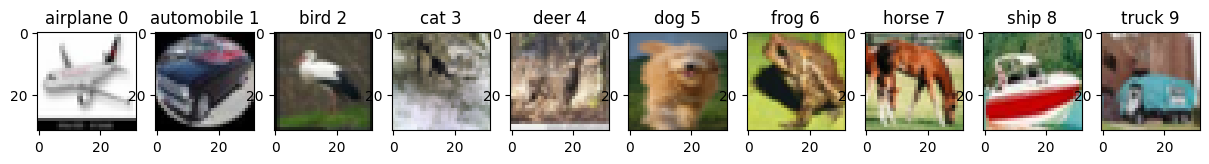

(10000, 32, 32, 3) (10000, 10) (10000, 32, 32, 3) (10000, 10)


In [2]:
# -----------------------------
# Load CIFAR-10
# -----------------------------
from keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# separate train val and test dataset
X_train = x_train[0:10000]
Y_train = to_categorical(y_train[0:10000], 10)  # one-hot encoding

X_val = x_train[20000:30000]
Y_val = to_categorical(y_train[20000:30000], 10)

X_test = x_test
Y_test = to_categorical(y_test, 10)

del x_train, y_train, x_test, y_test

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

# sample image of each label
labels = np.array(["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"])
plt.figure(figsize=(15,15))
for i in range(0, len(np.unique(np.argmax(Y_train, axis=1)))):
    rmd = np.random.choice(np.where(np.argmax(Y_train, axis=1) == i)[0], 1)
    plt.subplot(1,10,i+1)
    img = X_train[rmd]
    plt.imshow(img[0,:,:,:])
    plt.title(labels[i] + " " + str(np.argmax(Y_train, axis=1)[rmd][0]))
plt.show()

# check the shape of the data
print(X_train.shape, Y_train.shape, X_val.shape, Y_val.shape)

# Random forest

In [3]:
# ============================================================
# Random Forest baseline on raw pixels
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Labels: convert one-hot to class indices (RF needs 1D integer labels)
y_train_idx = np.argmax(Y_train, axis=1).astype(np.int64)
y_val_idx   = np.argmax(Y_val, axis=1).astype(np.int64)
y_test_idx  = np.argmax(Y_test, axis=1).astype(np.int64)

# Flatten images to vectors: (N, 32, 32, 3) -> (N, 3072)
X_train_rf = X_train.reshape(len(X_train), -1).astype(np.uint8)
X_val_rf   = X_val.reshape(len(X_val), -1).astype(np.uint8)
X_test_rf  = X_test.reshape(len(X_test), -1).astype(np.uint8)

# Random Forest (keep it modest; RF on full 10k x 3072 can be heavy)
rf = RandomForestClassifier(
    n_estimators=40,
    max_depth=None,
    n_jobs=-1,
    random_state=42,
    class_weight=None
)

rf.fit(X_train_rf, y_train_idx)

# Evaluate on test set
rf_test_pred = rf.predict(X_test_rf)
rf_test_acc = accuracy_score(y_test_idx, rf_test_pred)
print(f"Random Forest test accuracy: {rf_test_acc:.4f}")

# Optional: quick report (comment out if too verbose)
# print(classification_report(y_test_idx, rf_test_pred))

# Store results (so you can concat later with CNN results)
res_rf = pd.DataFrame({'Acc': [rf_test_acc]}, index=['Random Forest (raw pixels)'])
res_rf


Random Forest test accuracy: 0.3926


,Acc
Random Forest (raw pixels),0.3926


Think: what accuracy do you expect with no learning at all?

# Baseline CNN model

Baseline architecture considerations:
1) CIFAR-10 images are tiny (32×32). You don’t need a very deep network to start extracting useful patterns. keep small to train fast (not SOTA):
- Stage 1 (16 filters) learns low-level features: edges, corners, simple color/texture patterns.
- Stage 2 (32 filters) learns more complex combinations: parts of objects, textures, simple shapes.
2) Small 3×3 kernels are the standard building block (increases effective receptive field with fewer parameters and more nonlinearity).
3) Pooling reduces resolution and adds translation tolerance: MaxPooling2D((2,2)) halves spatial resolution:
- 32×32 → 16×16 after first pool
- 16×16 → 8×8 after second pool

4) Modern CNNs follow this rule almost universally: As spatial resolution decreases, channel depth increases:

- At 32×32: You don’t need many filters to detect simple edges. 16 filters is enough for basic low-level features.

- At 8×8: Each unit corresponds to a much larger part of the image. The network now needs more filters to encode different object parts and class-specific combinations. 32 filters (or more in larger networks) make sense here.

5) A small dense head keeps the model interpretable and limits memorization (overfitting).

In [4]:
# -----------------------------
# CNN
# -----------------------------
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation

model = Sequential()

model.add(Conv2D(16, (3,3), activation="relu", padding="same", input_shape=(32,32,3)))
model.add(Conv2D(16, (3,3), activation="relu", padding="same"))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(32, (3,3), activation="relu", padding="same"))
model.add(Conv2D(32, (3,3), activation="relu", padding="same"))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(128))
model.add(Activation('relu'))
model.add(Dense(10))
model.add(Activation('softmax'))

# use loss='sparse_categorical_crossentropy' when labels are integers instead of one-hot encoded vectors
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 280,218 (1.07 MB)

 Trainable params: 280,218 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:


# ============================================================
# Data and label preparation
# ============================================================

# 1) Convert images to float32 and scale to [0,1]
X_train_tf = X_train.astype("float32") / 255.0
X_val_tf   = X_val.astype("float32") / 255.0
X_test_tf  = X_test.astype("float32") / 255.0

print("Train min/max:", X_train_tf.min(), X_train_tf.max())

# 2) Convert one-hot labels to integer indices (required for sparse_categorical_crossentropy)
y_train_idx = np.argmax(Y_train, axis=1).astype("int64")
y_val_idx   = np.argmax(Y_val, axis=1).astype("int64")
y_test_idx  = np.argmax(Y_test, axis=1).astype("int64")

print("Label example:", y_train_idx[:10])

Train min/max: 0.0 1.0
Label example: [6 9 9 4 1 1 2 7 8 3]


Epoch 1/15
157/157 - 10s - 64ms/step - accuracy: 0.3198 - loss: 1.8523 - val_accuracy: 0.4365 - val_loss: 1.5445
Epoch 2/15
157/157 - 1s - 7ms/step - accuracy: 0.4684 - loss: 1.4677 - val_accuracy: 0.4847 - val_loss: 1.4103
Epoch 3/15
157/157 - 1s - 7ms/step - accuracy: 0.5316 - loss: 1.3055 - val_accuracy: 0.5165 - val_loss: 1.3816
Epoch 4/15
157/157 - 1s - 7ms/step - accuracy: 0.5912 - loss: 1.1488 - val_accuracy: 0.5596 - val_loss: 1.2631
Epoch 5/15
157/157 - 1s - 7ms/step - accuracy: 0.6303 - loss: 1.0413 - val_accuracy: 0.5639 - val_loss: 1.2354
Epoch 6/15
157/157 - 1s - 7ms/step - accuracy: 0.6674 - loss: 0.9395 - val_accuracy: 0.5908 - val_loss: 1.1669
Epoch 7/15
157/157 - 1s - 9ms/step - accuracy: 0.7060 - loss: 0.8292 - val_accuracy: 0.5857 - val_loss: 1.2175
Epoch 8/15
157/157 - 2s - 14ms/step - accuracy: 0.7438 - loss: 0.7352 - val_accuracy: 0.6008 - val_loss: 1.1793
Epoch 9/15
157/157 - 1s - 8ms/step - accuracy: 0.7670 - loss: 0.6650 - val_accuracy: 0.6108 - val_loss: 1.204

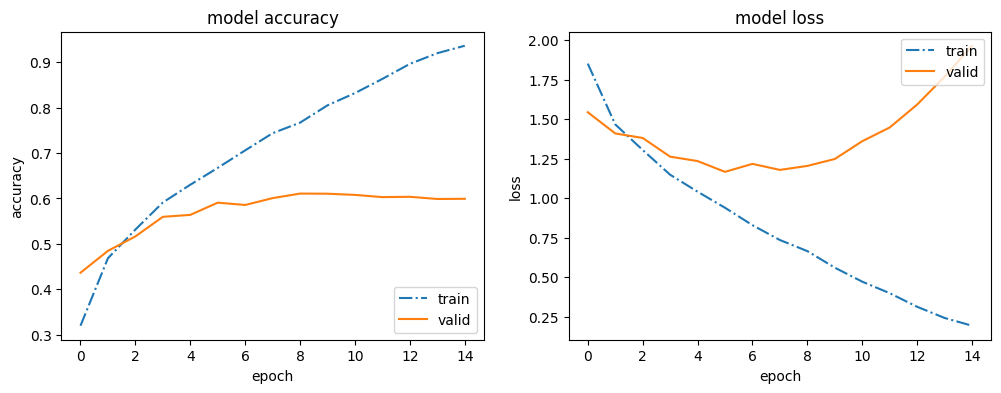

Test accuracy (model.evaluate): 0.5944
Test accuracy (manual):        0.5944


In [6]:


# -----------------------------
# Train (fit) + evaluate
# -----------------------------
EPOCHS = 15
BATCH_SIZE = 64

history = model.fit(
    X_train_tf, y_train_idx,
    validation_data=(X_val_tf, y_val_idx),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)

plot_history(history)

# Keras evaluation
cnn_test_loss, cnn_test_acc = model.evaluate(X_test_tf, y_test_idx, batch_size=BATCH_SIZE, verbose=0)
print(f"Test accuracy (model.evaluate): {cnn_test_acc:.4f}")

# manual accuracy (also possible)
probs = model.predict(X_test_tf, batch_size=BATCH_SIZE, verbose=0)
acc_manual = np.mean(np.argmax(probs, axis=1) == y_test_idx)
print(f"Test accuracy (manual):        {acc_manual:.4f}")


In [9]:
# after CNN evaluation gives cnn_test_acc
res_cnn = pd.DataFrame({'Acc': [cnn_test_acc]}, index=['CNN (from scratch)'])
pd.concat([res_rf, res_cnn])

,Acc
Random Forest (raw pixels),0.3926
CNN (from scratch),0.5944


# Dropout

Val_acc << train_acc means that our baseline model overfits (memorizes the training set). Dropout regulizes the model to prevent overfitting.

Note: we apply dropout on the fully connected layers and not the conv layers. why?
- Convolutional layers learn local spatial patterns (edges, textures, shapes).

- Standard Dropout randomly zeros individual activations.

- That breaks spatial continuity inside feature maps.

- It can damage low-level feature learning more than it helps regularization.

- In contrast: dense layers do not rely on spatial structure.

- Dropout works very naturally there by preventing co-adaptation of neurons.

- So in classical CNN design: Dropout → mostly in dense layers

- Conv layers → use BatchNorm or weight decay instead (see below)).

In [11]:
from tensorflow.keras.layers import Dropout
model_do = Sequential()

model_do.add(Conv2D(16, (3,3), activation="relu", padding="same", input_shape=(32,32,3)))
model_do.add(Conv2D(16, (3,3), activation="relu", padding="same"))
model_do.add(MaxPooling2D((2,2)))

model_do.add(Conv2D(32, (3,3), activation="relu", padding="same"))
model_do.add(Conv2D(32, (3,3), activation="relu", padding="same"))
model_do.add(MaxPooling2D((2,2)))

model_do.add(Flatten())
model_do.add(Dense(128))
model_do.add(Activation('relu'))
model_do.add(Dropout(0.5))   # <- only dropout


model_do.add(Dense(10))
model_do.add(Activation('softmax'))


model_do.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_do.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 280,218 (1.07 MB)

 Trainable params: 280,218 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
157/157 - 8s - 50ms/step - accuracy: 0.2668 - loss: 1.9593 - val_accuracy: 0.3762 - val_loss: 1.7068
Epoch 2/15
157/157 - 2s - 11ms/step - accuracy: 0.3842 - loss: 1.6691 - val_accuracy: 0.4633 - val_loss: 1.5135
Epoch 3/15
157/157 - 1s - 8ms/step - accuracy: 0.4462 - loss: 1.5253 - val_accuracy: 0.4935 - val_loss: 1.4450
Epoch 4/15
157/157 - 1s - 7ms/step - accuracy: 0.4841 - loss: 1.4196 - val_accuracy: 0.5324 - val_loss: 1.3170
Epoch 5/15
157/157 - 1s - 8ms/step - accuracy: 0.5161 - loss: 1.3360 - val_accuracy: 0.5463 - val_loss: 1.2512
Epoch 6/15
157/157 - 1s - 7ms/step - accuracy: 0.5440 - loss: 1.2547 - val_accuracy: 0.5617 - val_loss: 1.2402
Epoch 7/15
157/157 - 1s - 7ms/step - accuracy: 0.5668 - loss: 1.2047 - val_accuracy: 0.5754 - val_loss: 1.1854
Epoch 8/15
157/157 - 1s - 7ms/step - accuracy: 0.5929 - loss: 1.1374 - val_accuracy: 0.5814 - val_loss: 1.1578
Epoch 9/15
157/157 - 1s - 7ms/step - accuracy: 0.6128 - loss: 1.0772 - val_accuracy: 0.5912 - val_loss: 1.1516

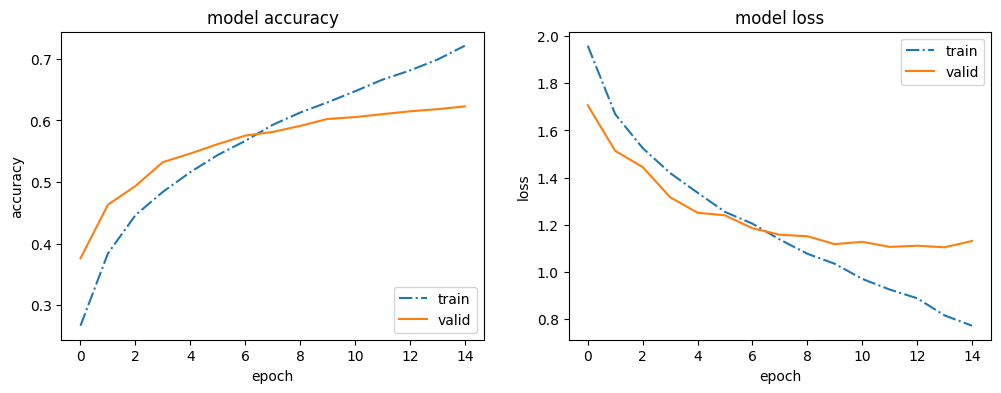

,Acc
Random Forest (raw pixels),0.3926
CNN (from scratch),0.5944
CNN + dropout,0.6174


In [12]:
history_do_raw = model_do.fit(
    X_train_tf, y_train_idx,
    validation_data=(X_val_tf, y_val_idx),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)

do_raw_test_loss, do_raw_test_acc = model_do.evaluate(X_test_tf, y_test_idx, batch_size=BATCH_SIZE, verbose=0)
print(f"Test accuracy (model_do.evaluate): {do_raw_test_acc:.4f}")

plot_history(history_do_raw)

res_do_raw = pd.DataFrame({"Acc":[do_raw_test_acc]},index=["CNN  + dropout"])
res_do_raw

# ------------------------------------------------------------
# Compare to baseline CNN results

# ------------------------------------------------------------
pd.concat([res_rf,res_cnn, res_do_raw])

## Effect of dropout

Training accuracy drops, test accuracy slightly increases. What does this imply? dropout largely removed overfitting (still some left, can add more dropout layers). No big accuracy improvement on test data means that the main classification difficulty is not due to overfitting on the training data but rather the quality of the data and /or the prediction capacity of the CNN model. In the following we will improve generalization by
1) Augmenting the data.
2) increasing the model capacity.

# Data augmentation
1. RandomFlip("horizontal"): randomly mirrors the image left↔right to make the model invariant to horizontal orientation changes.

2. ZeroPadding2D(4): adds a 4-pixel border of zeros around the image so later random crops can shift the content without losing size.

3. RandomCrop(32, 32): takes a random 32×32 window from a larger (padded) image to simulate small translations and framing changes.

The pipeline ds_train_aug does:

- Create dataset from arrays

- Shuffle samples

- Group into batches

- Apply augmentation to each batch

- Preload the next batch for performance

In [13]:
# ------------------------------------------------------------
# Data augmentation pipeline (applied only to training data)
# ------------------------------------------------------------
batch_size = 64

augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.ZeroPadding2D(4),
    tf.keras.layers.RandomCrop(32, 32),
], name="augment")


ds_train_aug = tf.data.Dataset.from_tensor_slices((X_train_tf, y_train_idx)).shuffle(10000).batch(batch_size).map(lambda x,y: (augment(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
ds_val = tf.data.Dataset.from_tensor_slices((X_val_tf, y_val_idx)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
ds_test = tf.data.Dataset.from_tensor_slices((X_test_tf, y_test_idx)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

## Visualize the augmentations

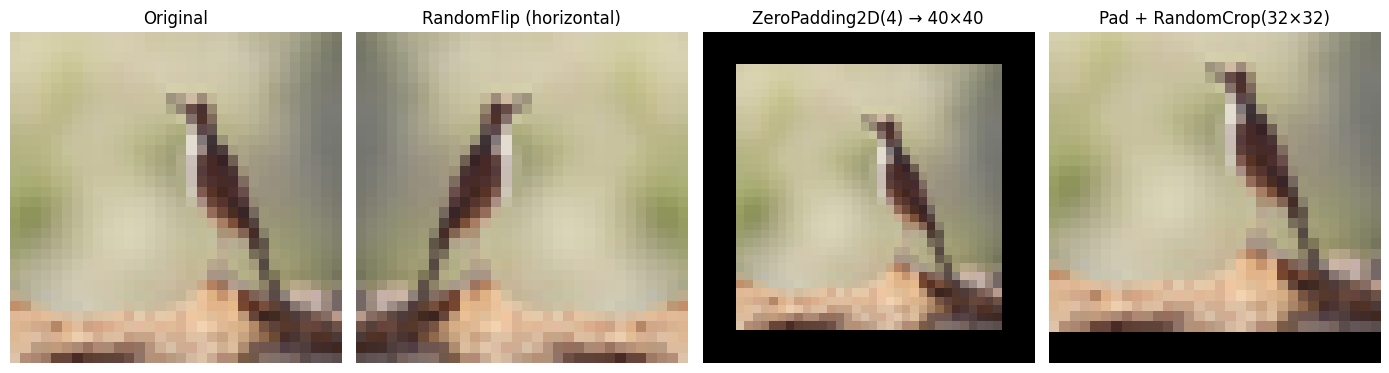

Example index: 402


In [14]:

import matplotlib.pyplot as plt

# Pick one example image (assumes X_train_tf exists in [0,1] and shape (N,32,32,3))
idx = np.random.randint(0, X_train_tf.shape[0])
img = X_train_tf[idx]  # (32,32,3), float32

# Define individual augmentation layers
flip_layer = tf.keras.layers.RandomFlip("horizontal")
pad_layer  = tf.keras.layers.ZeroPadding2D(4)
crop_layer = tf.keras.layers.RandomCrop(32, 32)

# Apply augmentations (need a batch dimension)
img_b = tf.expand_dims(img, axis=0)  # (1,32,32,3)

img_flip = flip_layer(img_b, training=True)[0]
img_pad  = pad_layer(img_b, training=True)[0]            # (40,40,3)

# RandomCrop expects input >= (32,32), so crop from padded image
img_crop = crop_layer(tf.expand_dims(img_pad, axis=0), training=True)[0]  # back to (32,32,3)

# Plot
plt.figure(figsize=(14,4))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(img_flip)
plt.title("RandomFlip (horizontal)")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(img_pad)
plt.title("ZeroPadding2D(4) → 40×40")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(img_crop)
plt.title("Pad + RandomCrop(32×32)")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Example index:", idx)


In [15]:
# ------------------------------------------------------------
# baseline CNN again
# ------------------------------------------------------------
model_aug = Sequential()
model_aug.add(Conv2D(16,(3,3),activation="relu",padding="same",input_shape=(32,32,3)))
model_aug.add(Conv2D(16,(3,3),activation="relu",padding="same"))
model_aug.add(MaxPooling2D((2,2)))
model_aug.add(Conv2D(32,(3,3),activation="relu",padding="same"))
model_aug.add(Conv2D(32,(3,3),activation="relu",padding="same"))
model_aug.add(MaxPooling2D((2,2)))
model_aug.add(Flatten())
model_aug.add(Dense(128))
model_aug.add(Activation('relu'))
model_aug.add(Dense(10))
model_aug.add(Activation('softmax'))
model_aug.compile(loss="sparse_categorical_crossentropy",optimizer="adam",metrics=["accuracy"])
model_aug.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 280,218 (1.07 MB)

 Trainable params: 280,218 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
157/157 - 7s - 44ms/step - accuracy: 0.2540 - loss: 2.0115 - val_accuracy: 0.3240 - val_loss: 1.8004
Epoch 2/15
157/157 - 2s - 15ms/step - accuracy: 0.3733 - loss: 1.6974 - val_accuracy: 0.4478 - val_loss: 1.5099
Epoch 3/15
157/157 - 2s - 13ms/step - accuracy: 0.4311 - loss: 1.5564 - val_accuracy: 0.4953 - val_loss: 1.3989
Epoch 4/15
157/157 - 2s - 10ms/step - accuracy: 0.4715 - loss: 1.4627 - val_accuracy: 0.5033 - val_loss: 1.3717
Epoch 5/15
157/157 - 3s - 17ms/step - accuracy: 0.4859 - loss: 1.4166 - val_accuracy: 0.5147 - val_loss: 1.3489
Epoch 6/15
157/157 - 1s - 9ms/step - accuracy: 0.5090 - loss: 1.3624 - val_accuracy: 0.5078 - val_loss: 1.3454
Epoch 7/15
157/157 - 1s - 9ms/step - accuracy: 0.5286 - loss: 1.2980 - val_accuracy: 0.5616 - val_loss: 1.2124
Epoch 8/15
157/157 - 3s - 22ms/step - accuracy: 0.5486 - loss: 1.2485 - val_accuracy: 0.5941 - val_loss: 1.1484
Epoch 9/15
157/157 - 2s - 11ms/step - accuracy: 0.5659 - loss: 1.2099 - val_accuracy: 0.6018 - val_loss: 1

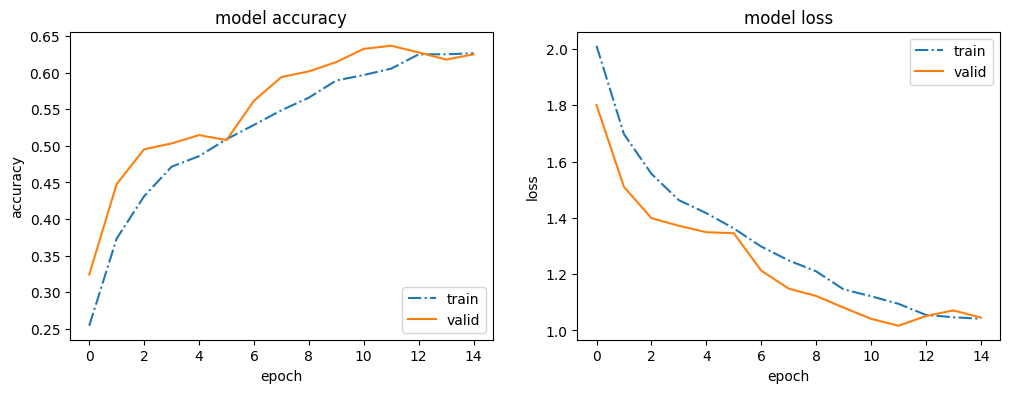

Augmented training model test accuracy: 0.6207000017166138


,Acc
Random Forest (raw pixels),0.3926
CNN (from scratch),0.5944
CNN + dropout,0.6174
CNN + augmentation,0.6207


In [16]:
# ------------------------------------------------------------
# Train on augmented data, validate on the same val set
# ------------------------------------------------------------
epochs = 15
history_aug = model_aug.fit(ds_train_aug, validation_data=ds_val, epochs=epochs, verbose=2)

plot_history(history_aug)

# ------------------------------------------------------------
# Test on the same test data
# ------------------------------------------------------------
aug_test_loss, aug_test_acc = model_aug.evaluate(ds_test, verbose=0)
print("Augmented training model test accuracy:", aug_test_acc)

# ------------------------------------------------------------
# Compare to baseline CNN results
# res_cnn should exist from your earlier baseline CNN run
# If res_cnn doesn't exist, create it from your stored baseline test accuracy variable
# ------------------------------------------------------------
res_aug = pd.DataFrame({"Acc":[aug_test_acc]}, index=["CNN + augmentation"])
pd.concat([res_rf,res_cnn, res_do_raw,res_aug])


## Effect of augmentation

augmentation makes the training problem harder:
The model sees shifted / flipped / cropped images --> Can no longer memorize exact pixel positions

--> Training accuracy further decreases, this is expected and healthy.

--> Data augmentation helps generalize: no overfitting and thus higher test accuracy. Further improvements could be possibly achieved if we increase the model's capability with more conv layers.

# Increase CNN capacity

There are 2 main ways to increase capacity in a CNN:

1. Go deeper (add more Conv layers)

2. Go wider (increase number of filters per layer)

Both increase representational power, but they behave differently. Increasing the number of feature maps we

- let each spatial level learn more patterns

- Increase modeling capacity without changing gradient depth --> keep optimization stable

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,274 (2.26 MB)

 Trainable params: 591,274 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
157/157 - 10s - 62ms/step - accuracy: 0.2731 - loss: 1.9848 - val_accuracy: 0.3800 - val_loss: 1.6788
Epoch 2/15
157/157 - 4s - 26ms/step - accuracy: 0.3908 - loss: 1.6610 - val_accuracy: 0.4666 - val_loss: 1.4529
Epoch 3/15
157/157 - 2s - 11ms/step - accuracy: 0.4341 - loss: 1.5439 - val_accuracy: 0.4847 - val_loss: 1.4051
Epoch 4/15
157/157 - 2s - 12ms/step - accuracy: 0.4841 - loss: 1.4109 - val_accuracy: 0.4991 - val_loss: 1.3750
Epoch 5/15
157/157 - 2s - 12ms/step - accuracy: 0.5232 - loss: 1.3344 - val_accuracy: 0.5494 - val_loss: 1.2725
Epoch 6/15
157/157 - 2s - 14ms/step - accuracy: 0.5446 - loss: 1.2721 - val_accuracy: 0.6058 - val_loss: 1.1055
Epoch 7/15
157/157 - 2s - 13ms/step - accuracy: 0.5678 - loss: 1.2073 - val_accuracy: 0.6076 - val_loss: 1.1114
Epoch 8/15
157/157 - 2s - 11ms/step - accuracy: 0.5845 - loss: 1.1510 - val_accuracy: 0.6153 - val_loss: 1.0772
Epoch 9/15
157/157 - 2s - 11ms/step - accuracy: 0.6148 - loss: 1.0866 - val_accuracy: 0.6338 - val_loss

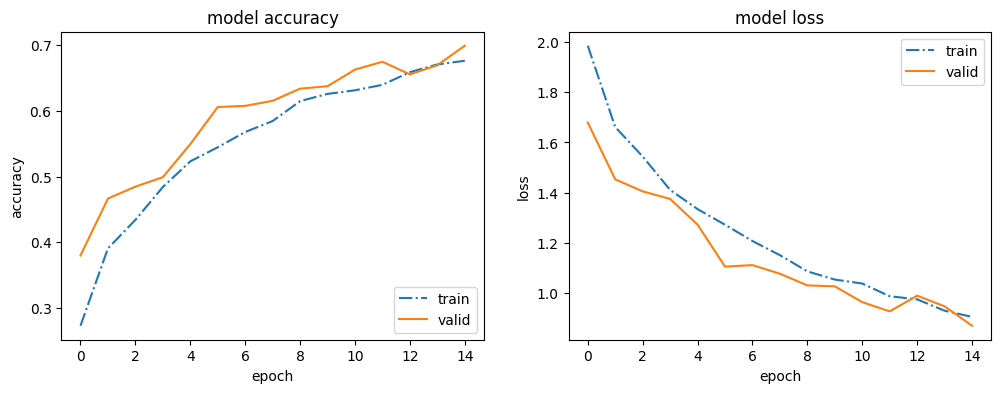

CNN (wider) + augmentation test accuracy: 0.6891000270843506


,Acc
Random Forest (raw pixels),0.3926
CNN (from scratch),0.5944
CNN + dropout,0.6174
CNN + augmentation,0.6207
CNN (wider) + augmentation,0.6891


In [17]:
model_aug_bigconv = Sequential()
model_aug_bigconv.add(Conv2D(32,(3,3),activation="relu",padding="same",input_shape=(32,32,3))) # x2 more filters
model_aug_bigconv.add(Conv2D(32,(3,3),activation="relu",padding="same"))                       # x2 more filters
model_aug_bigconv.add(MaxPooling2D((2,2)))
model_aug_bigconv.add(Conv2D(64,(3,3),activation="relu",padding="same"))                       # x2 more filters
model_aug_bigconv.add(Conv2D(64,(3,3),activation="relu",padding="same"))                       # x2 more filters
model_aug_bigconv.add(MaxPooling2D((2,2)))
model_aug_bigconv.add(Flatten())
model_aug_bigconv.add(Dense(128))
model_aug_bigconv.add(Activation("relu"))
model_aug_bigconv.add(Dense(10))
model_aug_bigconv.add(Activation("softmax"))
model_aug_bigconv.compile(loss="sparse_categorical_crossentropy",optimizer="adam",metrics=["accuracy"])
model_aug_bigconv.summary()

history_aug_bigconv = model_aug_bigconv.fit(ds_train_aug,validation_data=ds_val,epochs=epochs,verbose=2)
plot_history(history_aug_bigconv)

bigconv_test_loss,bigconv_test_acc = model_aug_bigconv.evaluate(ds_test,verbose=0)
print("CNN (wider) + augmentation test accuracy:",bigconv_test_acc)

res_aug_bigconv = pd.DataFrame({"Acc":[bigconv_test_acc]},index=["CNN (wider) + augmentation"])
pd.concat([res_rf,res_cnn, res_do_raw,res_aug,res_aug_bigconv])


# Going deeper

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 32, 32, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 204,570 (799.10 KB)

 Trainable params: 204,570 (799.10 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
157/157 - 10s - 62ms/step - accuracy: 0.2038 - loss: 2.1175 - val_accuracy: 0.2553 - val_loss: 1.9830
Epoch 2/30
157/157 - 2s - 10ms/step - accuracy: 0.3297 - loss: 1.8023 - val_accuracy: 0.3757 - val_loss: 1.7658
Epoch 3/30
157/157 - 3s - 16ms/step - accuracy: 0.3853 - loss: 1.6590 - val_accuracy: 0.4175 - val_loss: 1.5794
Epoch 4/30
157/157 - 2s - 13ms/step - accuracy: 0.4343 - loss: 1.5365 - val_accuracy: 0.4696 - val_loss: 1.4224
Epoch 5/30
157/157 - 2s - 14ms/step - accuracy: 0.4684 - loss: 1.4497 - val_accuracy: 0.5169 - val_loss: 1.3159
Epoch 6/30
157/157 - 2s - 10ms/step - accuracy: 0.4980 - loss: 1.3692 - val_accuracy: 0.5508 - val_loss: 1.2721
Epoch 7/30
157/157 - 2s - 10ms/step - accuracy: 0.5236 - loss: 1.3046 - val_accuracy: 0.5512 - val_loss: 1.2389
Epoch 8/30
157/157 - 3s - 17ms/step - accuracy: 0.5428 - loss: 1.2596 - val_accuracy: 0.5370 - val_loss: 1.2633
Epoch 9/30
157/157 - 2s - 10ms/step - accuracy: 0.5653 - loss: 1.1967 - val_accuracy: 0.5981 - val_loss

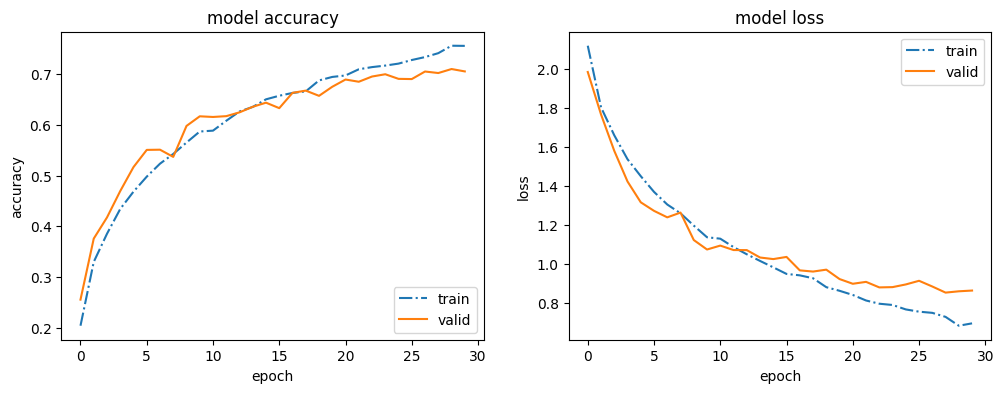

Deeper CNN  + augmentation test accuracy: 0.6976000070571899


,Acc
Random Forest (raw pixels),0.3926
CNN (from scratch),0.5944
CNN + dropout,0.6174
CNN + augmentation,0.6207
CNN (wider) + augmentation,0.6891
CNN (deeper) + augmentation,0.6976


In [18]:


model_deeper3 = Sequential()
model_deeper3.add(Conv2D(16,(3,3),activation="relu",padding="same",input_shape=(32,32,3)))
model_deeper3.add(Conv2D(16,(3,3),activation="relu",padding="same"))
model_deeper3.add(MaxPooling2D((2,2)))
model_deeper3.add(Conv2D(32,(3,3),activation="relu",padding="same"))
model_deeper3.add(Conv2D(32,(3,3),activation="relu",padding="same"))
model_deeper3.add(MaxPooling2D((2,2)))
model_deeper3.add(Conv2D(64,(3,3),activation="relu",padding="same"))
model_deeper3.add(Conv2D(64,(3,3),activation="relu",padding="same"))
model_deeper3.add(MaxPooling2D((2,2)))
model_deeper3.add(Flatten())
model_deeper3.add(Dense(128))
model_deeper3.add(Activation("relu"))
model_deeper3.add(Dense(10))
model_deeper3.add(Activation("softmax"))
model_deeper3.compile(loss="sparse_categorical_crossentropy",optimizer="adam",metrics=["accuracy"])
model_deeper3.summary()

epochs = 30 # train longer
history_deeper3 = model_deeper3.fit(ds_train_aug,validation_data=ds_val,epochs=epochs,verbose=2)
plot_history(history_deeper3)

deeper3_test_loss,deeper3_test_acc = model_deeper3.evaluate(ds_test,verbose=0)
print("Deeper CNN  + augmentation test accuracy:",deeper3_test_acc)

res_deeper3 = pd.DataFrame({"Acc":[deeper3_test_acc]},index=["CNN (deeper) + augmentation"])


# ------------------------------------------------------------
# Compare to baseline CNN results

# ------------------------------------------------------------
pd.concat([res_rf,res_cnn, res_do_raw,res_aug,res_aug_bigconv,res_deeper3])


# Both wider and deeper

Note : now we must also train longer.


aim: get to overfitting to show the effect of dropout /BN

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,570 (2.10 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
157/157 - 10s - 64ms/step - accuracy: 0.2250 - loss: 2.0573 - val_accuracy: 0.3350 - val_loss: 1.8223
Epoch 2/30
157/157 - 2s - 12ms/step - accuracy: 0.3476 - loss: 1.7353 - val_accuracy: 0.4155 - val_loss: 1.5692
Epoch 3/30
157/157 - 2s - 12ms/step - accuracy: 0.4092 - loss: 1.5889 - val_accuracy: 0.4329 - val_loss: 1.5240
Epoch 4/30
157/157 - 2s - 12ms/step - accuracy: 0.4462 - loss: 1.4814 - val_accuracy: 0.5155 - val_loss: 1.3412
Epoch 5/30
157/157 - 2s - 12ms/step - accuracy: 0.4922 - loss: 1.3784 - val_accuracy: 0.5149 - val_loss: 1.3310
Epoch 6/30
157/157 - 2s - 14ms/step - accuracy: 0.5290 - loss: 1.2869 - val_accuracy: 0.5393 - val_loss: 1.2867
Epoch 7/30
157/157 - 2s - 16ms/step - accuracy: 0.5482 - loss: 1.2340 - val_accuracy: 0.5691 - val_loss: 1.1948
Epoch 8/30
157/157 - 2s - 12ms/step - accuracy: 0.5784 - loss: 1.1788 - val_accuracy: 0.5918 - val_loss: 1.1513
Epoch 9/30
157/157 - 2s - 12ms/step - accuracy: 0.5983 - loss: 1.1032 - val_accuracy: 0.6125 - val_loss

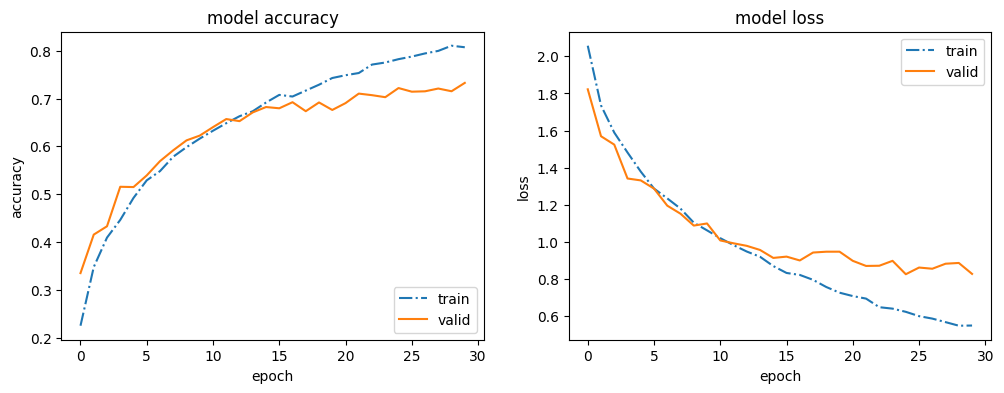

Deeper and wider CNN + augmentation test accuracy: 0.7202000021934509


,Acc
Random Forest (raw pixels),0.3926
CNN (from scratch),0.5944
CNN + dropout,0.6174
CNN + augmentation,0.6207
CNN (wider) + augmentation,0.6891
CNN (deeper) + augmentation,0.6976
CNN deeper & wider + augmentation,0.7202


In [19]:
model_deeper3 = Sequential()
model_deeper3.add(Conv2D(32,(3,3),activation="relu",padding="same",input_shape=(32,32,3)))
model_deeper3.add(Conv2D(32,(3,3),activation="relu",padding="same"))
model_deeper3.add(MaxPooling2D((2,2)))
model_deeper3.add(Conv2D(64,(3,3),activation="relu",padding="same"))
model_deeper3.add(Conv2D(64,(3,3),activation="relu",padding="same"))
model_deeper3.add(MaxPooling2D((2,2)))
model_deeper3.add(Conv2D(128,(3,3),activation="relu",padding="same"))
model_deeper3.add(Conv2D(128,(3,3),activation="relu",padding="same"))
model_deeper3.add(MaxPooling2D((2,2)))
model_deeper3.add(Flatten())
model_deeper3.add(Dense(128))
model_deeper3.add(Activation("relu"))
model_deeper3.add(Dense(10))
model_deeper3.add(Activation("softmax"))
model_deeper3.compile(loss="sparse_categorical_crossentropy",optimizer="adam",metrics=["accuracy"])
model_deeper3.summary()


epochs = 30 # train longer

history_deeper3 = model_deeper3.fit(ds_train_aug,validation_data=ds_val,epochs=epochs,verbose=2)
plot_history(history_deeper3)

deeper3_test_loss,deeper3_test_acc = model_deeper3.evaluate(ds_test,verbose=0)
print("Deeper and wider CNN + augmentation test accuracy:",deeper3_test_acc)

res_bigger = pd.DataFrame({"Acc":[deeper3_test_acc]},index=["CNN deeper & wider + augmentation"])
res_bigger

# ------------------------------------------------------------
# Compare to baseline CNN results

# ------------------------------------------------------------
pd.concat([res_rf,res_cnn, res_do_raw,res_aug,res_aug_bigconv,res_deeper3,res_bigger])



1️⃣ Large head, no augmentation

Train >> Val → overfitting → regularization helps

2️⃣ Augmentation

Train ≈ Val → reduced overfitting

3️⃣ Augmentation + deeper trunk

Now capacity limits performance → need better features

# Batch Normalization
try to improve a large model using BN

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 8, 8, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 2048)           │             

 Total params: 552,298 (2.11 MB)

 Trainable params: 551,146 (2.10 MB)

 Non-trainable params: 1,152 (4.50 KB)

Epoch 1/45
157/157 - 15s - 94ms/step - accuracy: 0.3861 - loss: 1.6999 - val_accuracy: 0.0967 - val_loss: 4.0948
Epoch 2/45
157/157 - 2s - 15ms/step - accuracy: 0.4959 - loss: 1.3935 - val_accuracy: 0.2239 - val_loss: 2.6705
Epoch 3/45
157/157 - 2s - 14ms/step - accuracy: 0.5585 - loss: 1.2166 - val_accuracy: 0.4293 - val_loss: 1.6784
Epoch 4/45
157/157 - 3s - 16ms/step - accuracy: 0.6222 - loss: 1.0672 - val_accuracy: 0.5371 - val_loss: 1.2959
Epoch 5/45
157/157 - 2s - 13ms/step - accuracy: 0.6447 - loss: 0.9852 - val_accuracy: 0.5813 - val_loss: 1.2089
Epoch 6/45
157/157 - 3s - 17ms/step - accuracy: 0.6807 - loss: 0.9013 - val_accuracy: 0.5485 - val_loss: 1.3277
Epoch 7/45
157/157 - 5s - 29ms/step - accuracy: 0.7030 - loss: 0.8417 - val_accuracy: 0.6604 - val_loss: 1.0151
Epoch 8/45
157/157 - 2s - 14ms/step - accuracy: 0.7174 - loss: 0.7965 - val_accuracy: 0.6913 - val_loss: 0.8818
Epoch 9/45
157/157 - 2s - 13ms/step - accuracy: 0.7418 - loss: 0.7354 - val_accuracy: 0.5956 - val_loss

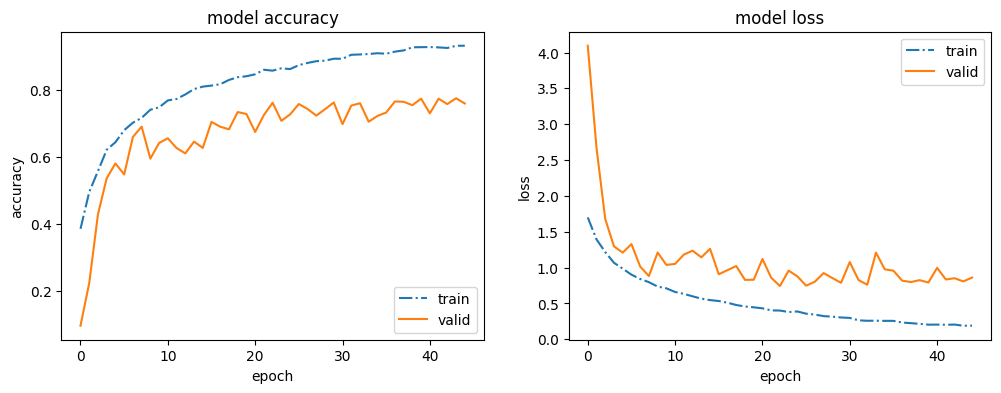

Deeper & wider CNN  + BN + augmentation test accuracy: 0.7513999938964844


,Acc
CNN (from scratch),0.5944
CNN + augmentation,0.6207
CNN (wider) + augmentation,0.6891
CNN (deeper) + augmentation,0.6976
CNN deeper & wider + augmentation,0.7202
CNN deeper & wider + BN + augmentation,0.7514


In [20]:

from tensorflow.keras.layers import BatchNormalization
# use_bias = False:
#Because BatchNorm already includes a learnable shift (bias) term.
#So the bias in the preceding Conv/Dense layer becomes redundant

model_deeper3_bn = Sequential()

model_deeper3_bn.add(Conv2D(32,(3,3),padding="same",input_shape=(32,32,3),use_bias=False))
model_deeper3_bn.add(BatchNormalization())
model_deeper3_bn.add(Activation("relu"))

model_deeper3_bn.add(Conv2D(32,(3,3),padding="same",use_bias=False))
model_deeper3_bn.add(BatchNormalization())
model_deeper3_bn.add(Activation("relu"))

model_deeper3_bn.add(MaxPooling2D((2,2)))

model_deeper3_bn.add(Conv2D(64,(3,3),padding="same",use_bias=False))
model_deeper3_bn.add(BatchNormalization())
model_deeper3_bn.add(Activation("relu"))

model_deeper3_bn.add(Conv2D(64,(3,3),padding="same",use_bias=False))
model_deeper3_bn.add(BatchNormalization())
model_deeper3_bn.add(Activation("relu"))

model_deeper3_bn.add(MaxPooling2D((2,2)))

model_deeper3_bn.add(Conv2D(128,(3,3),padding="same",use_bias=False))
model_deeper3_bn.add(BatchNormalization())
model_deeper3_bn.add(Activation("relu"))

model_deeper3_bn.add(Conv2D(128,(3,3),padding="same",use_bias=False))
model_deeper3_bn.add(BatchNormalization())
model_deeper3_bn.add(Activation("relu"))

model_deeper3_bn.add(MaxPooling2D((2,2)))

model_deeper3_bn.add(Flatten())

model_deeper3_bn.add(Dense(128,use_bias=False))
model_deeper3_bn.add(BatchNormalization())
model_deeper3_bn.add(Activation("relu"))

model_deeper3_bn.add(Dense(10))
model_deeper3_bn.add(Activation("softmax"))

model_deeper3_bn.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model_deeper3_bn.summary()


epochs = 45 # train longer
history_deeper3_bn = model_deeper3_bn.fit(
    ds_train_aug,
    validation_data=ds_val,
    epochs=epochs,
    verbose=2
)

plot_history(history_deeper3_bn)

deeper3_bn_test_loss, deeper3_bn_test_acc = model_deeper3_bn.evaluate(ds_test, verbose=0)
print("Deeper & wider CNN  + BN + augmentation test accuracy:", deeper3_bn_test_acc)

res_deeper3_bn = pd.DataFrame(
    {"Acc":[deeper3_bn_test_acc]},
    index=["CNN deeper & wider + BN + augmentation"]
)

pd.concat([res_cnn, res_aug, res_aug_bigconv, res_deeper3, res_bigger, res_deeper3_bn])


In [ ]:
## Effect of BN

## Effect of BN
With BN and longer training we increase training and testing accuracy.
BN improves optimization dynamics, not generalization strength.

--> Increase train accuracy faster than test accuracy.
--> Introduce regularization in addition using weight decay.


# Weight decay

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_44 (Conv2D)              │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_30 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_31 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_32 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_33 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_34 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 8, 8, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_35 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 2048)           │             

 Total params: 552,298 (2.11 MB)

 Trainable params: 551,146 (2.10 MB)

 Non-trainable params: 1,152 (4.50 KB)

Epoch 1/45
157/157 - 16s - 101ms/step - accuracy: 0.4039 - loss: 1.7082 - val_accuracy: 0.0967 - val_loss: 3.9772
Epoch 2/45
157/157 - 3s - 18ms/step - accuracy: 0.5090 - loss: 1.4224 - val_accuracy: 0.1884 - val_loss: 3.4829
Epoch 3/45
157/157 - 2s - 14ms/step - accuracy: 0.5642 - loss: 1.2760 - val_accuracy: 0.4633 - val_loss: 1.6549
Epoch 4/45
157/157 - 2s - 14ms/step - accuracy: 0.6263 - loss: 1.1211 - val_accuracy: 0.4242 - val_loss: 2.0419
Epoch 5/45
157/157 - 2s - 14ms/step - accuracy: 0.6548 - loss: 1.0450 - val_accuracy: 0.5488 - val_loss: 1.4283
Epoch 6/45
157/157 - 3s - 16ms/step - accuracy: 0.6887 - loss: 0.9678 - val_accuracy: 0.6300 - val_loss: 1.1893
Epoch 7/45
157/157 - 2s - 16ms/step - accuracy: 0.7087 - loss: 0.9064 - val_accuracy: 0.6920 - val_loss: 0.9478
Epoch 8/45
157/157 - 2s - 15ms/step - accuracy: 0.7320 - loss: 0.8445 - val_accuracy: 0.6266 - val_loss: 1.1989
Epoch 9/45
157/157 - 2s - 14ms/step - accuracy: 0.7457 - loss: 0.8276 - val_accuracy: 0.6818 - val_los

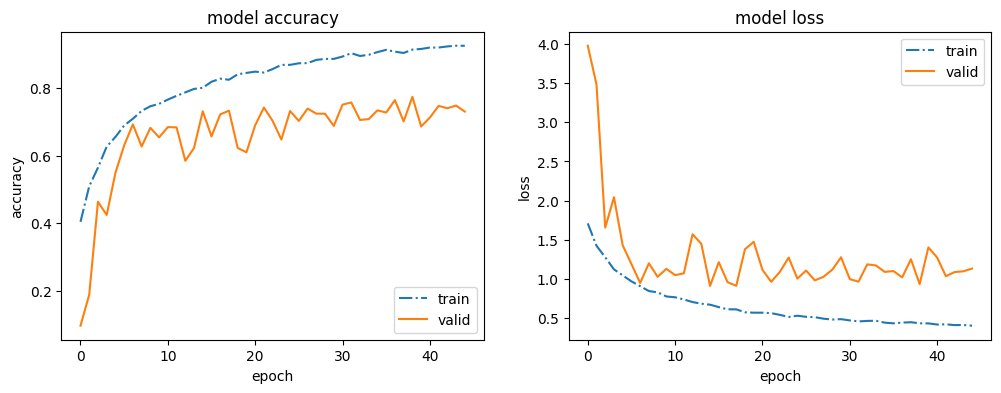

Deeper CNN  + BN + augmentation + weight decay test accuracy: 0.7251999974250793


,Acc
CNN (from scratch),0.5944
CNN + augmentation,0.6207
CNN (wider) + augmentation,0.6891
CNN (deeper) + augmentation,0.6976
CNN deeper & wider + augmentation,0.7202
CNN deeper & wider + BN + augmentation,0.7514
CNN deeper + BN + aug + wd=0.0001,0.7252


In [22]:
from tensorflow.keras import regularizers

wd = 1e-4  # weight decay (L2). common CIFAR starting point

model_deeper3_bn_wd = Sequential()

model_deeper3_bn_wd.add(Conv2D(32,(3,3),padding="same",input_shape=(32,32,3),use_bias=False,kernel_regularizer=regularizers.l2(wd)))
model_deeper3_bn_wd.add(BatchNormalization())
model_deeper3_bn_wd.add(Activation("relu"))

model_deeper3_bn_wd.add(Conv2D(32,(3,3),padding="same",use_bias=False,kernel_regularizer=regularizers.l2(wd)))
model_deeper3_bn_wd.add(BatchNormalization())
model_deeper3_bn_wd.add(Activation("relu"))

model_deeper3_bn_wd.add(MaxPooling2D((2,2)))

model_deeper3_bn_wd.add(Conv2D(64,(3,3),padding="same",use_bias=False,kernel_regularizer=regularizers.l2(wd)))
model_deeper3_bn_wd.add(BatchNormalization())
model_deeper3_bn_wd.add(Activation("relu"))

model_deeper3_bn_wd.add(Conv2D(64,(3,3),padding="same",use_bias=False,kernel_regularizer=regularizers.l2(wd)))
model_deeper3_bn_wd.add(BatchNormalization())
model_deeper3_bn_wd.add(Activation("relu"))

model_deeper3_bn_wd.add(MaxPooling2D((2,2)))

model_deeper3_bn_wd.add(Conv2D(128,(3,3),padding="same",use_bias=False,kernel_regularizer=regularizers.l2(wd)))
model_deeper3_bn_wd.add(BatchNormalization())
model_deeper3_bn_wd.add(Activation("relu"))

model_deeper3_bn_wd.add(Conv2D(128,(3,3),padding="same",use_bias=False,kernel_regularizer=regularizers.l2(wd)))
model_deeper3_bn_wd.add(BatchNormalization())
model_deeper3_bn_wd.add(Activation("relu"))

model_deeper3_bn_wd.add(MaxPooling2D((2,2)))

model_deeper3_bn_wd.add(Flatten())

model_deeper3_bn_wd.add(Dense(128,use_bias=False,kernel_regularizer=regularizers.l2(wd)))
model_deeper3_bn_wd.add(BatchNormalization())
model_deeper3_bn_wd.add(Activation("relu"))

model_deeper3_bn_wd.add(Dense(10,kernel_regularizer=regularizers.l2(wd)))
model_deeper3_bn_wd.add(Activation("softmax"))

model_deeper3_bn_wd.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model_deeper3_bn_wd.summary()

epochs = 45

history_deeper3_bn_wd = model_deeper3_bn_wd.fit(
    ds_train_aug,
    validation_data=ds_val,
    epochs=epochs,
    verbose=2
)

plot_history(history_deeper3_bn_wd)

deeper3_bn_wd_test_loss, deeper3_bn_wd_test_acc = model_deeper3_bn_wd.evaluate(ds_test, verbose=0)
print("Deeper CNN  + BN + augmentation + weight decay test accuracy:", deeper3_bn_wd_test_acc)

res_deeper3_bn_wd = pd.DataFrame(
    {"Acc":[deeper3_bn_wd_test_acc]},
    index=[f"CNN deeper + BN + aug + wd={wd:g}"]
)

pd.concat([res_cnn, res_aug, res_aug_bigconv, res_deeper3, res_bigger, res_deeper3_bn, res_deeper3_bn_wd])


## Effect of Weight decay
BatchNorm is primarily an optimization tool.
Weight decay, dropout, and augmentation are regularization tools.

# Error analysis

# Confusion matrix

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step


<Figure size 800x800 with 0 Axes>

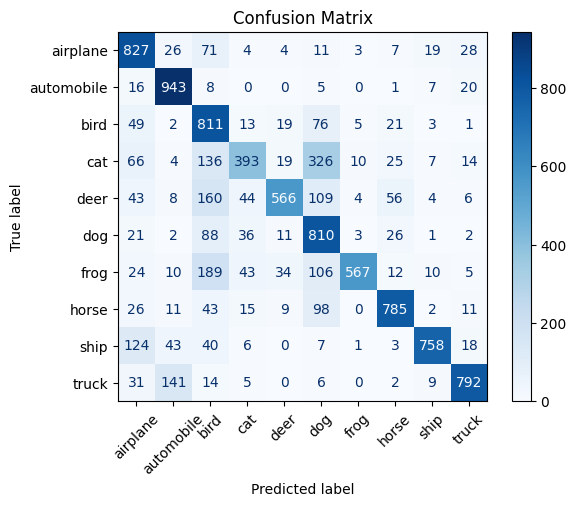

In [23]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions
y_pred_probs = model_deeper3_bn_wd.predict(ds_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_idx  # your true labels (not one-hot)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=labels)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


# Per-class accuracy

In [24]:
class_acc = cm.diagonal() / cm.sum(axis=1)

for i, acc in enumerate(class_acc):
    print(f"{labels[i]:12s}: {acc:.3f}")


airplane    : 0.827
automobile  : 0.943
bird        : 0.811
cat         : 0.393
deer        : 0.566
dog         : 0.810
frog        : 0.567
horse       : 0.785
ship        : 0.758
truck       : 0.792


# Visualize misclassified examples

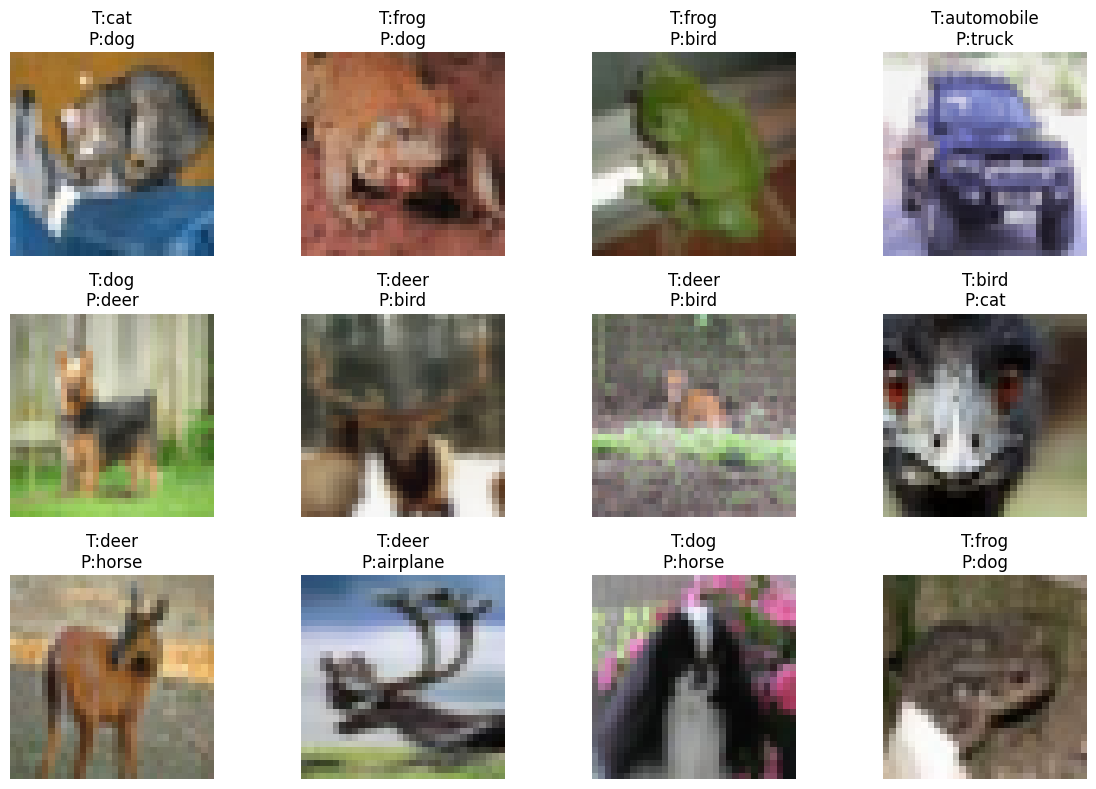

In [25]:
mis_idx = np.where(y_pred != y_true)[0]

plt.figure(figsize=(12,8))
for i in range(12):
    idx = mis_idx[i]
    plt.subplot(3,4,i+1)
    plt.imshow(X_test_tf[idx])
    plt.title(f"T:{labels[y_true[idx]]}\nP:{labels[y_pred[idx]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()


# High confidence errors

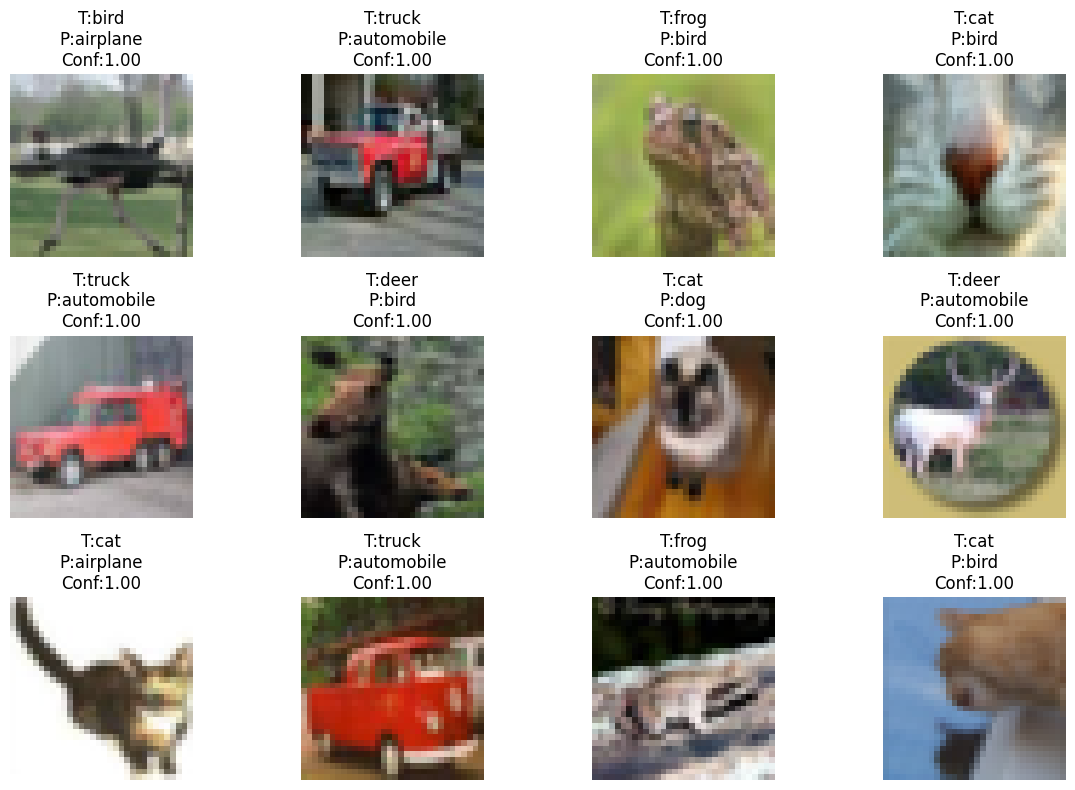

In [26]:
conf = np.max(y_pred_probs, axis=1)
wrong_conf = conf[mis_idx]

high_conf_errors = mis_idx[np.argsort(-wrong_conf)]

plt.figure(figsize=(12,8))
for i in range(12):
    idx = high_conf_errors[i]
    plt.subplot(3,4,i+1)
    plt.imshow(X_test_tf[idx])
    plt.title(f"T:{labels[y_true[idx]]}\nP:{labels[y_pred[idx]]}\nConf:{conf[idx]:.2f}")
    plt.axis("off")
plt.tight_layout()
plt.show()


# Low confidence correct classifications

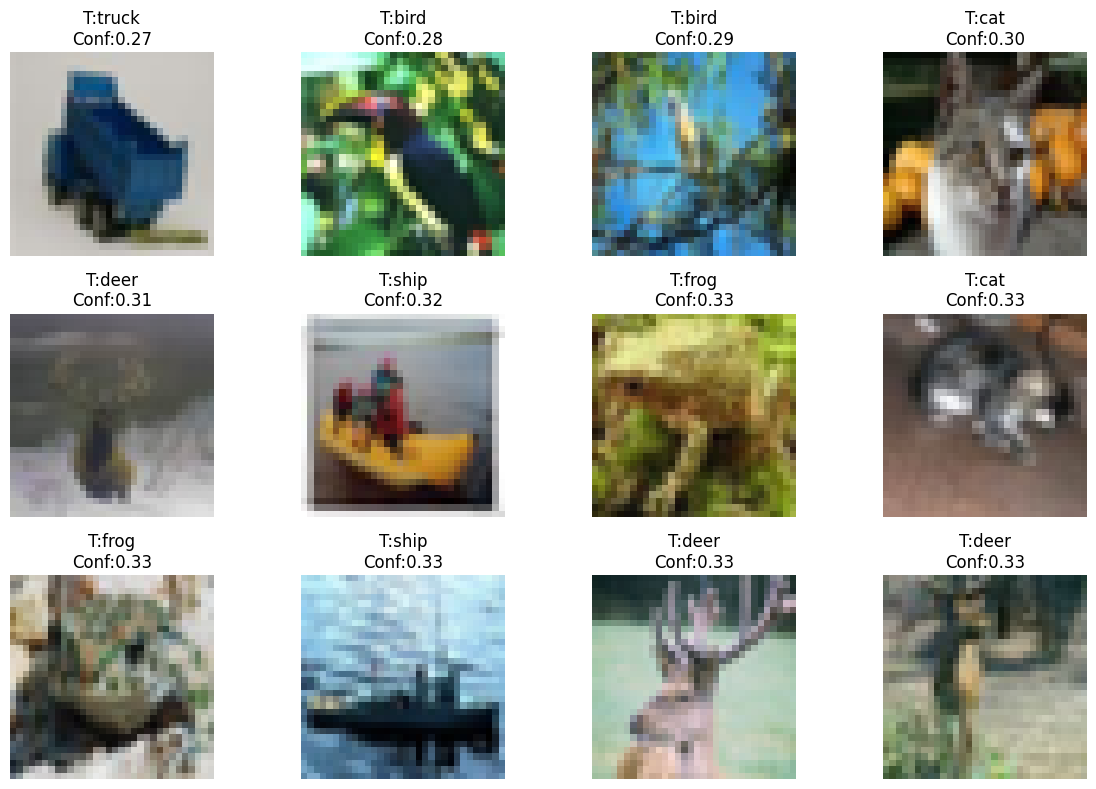

In [27]:
correct_idx = np.where(y_pred == y_true)[0]
low_conf_correct = correct_idx[np.argsort(conf[correct_idx])]

plt.figure(figsize=(12,8))
for i in range(12):
    idx = low_conf_correct[i]
    plt.subplot(3,4,i+1)
    plt.imshow(X_test_tf[idx])
    plt.title(f"T:{labels[y_true[idx]]}\nConf:{conf[idx]:.2f}")
    plt.axis("off")
plt.tight_layout()
plt.show()


## 🔧 **YOUR TASK:**
- Try to beat the performace of the best network with your own neural network.  
- you might want to combine some approaches from above
- dont forget to normalize also the testset if you use normalization (which you should use anyway😉)







In [ ]:
### YOUR CODE ###